<a href="https://colab.research.google.com/github/arunangshu19/PINN/blob/schrodinger/radial_H_atom_all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Running l=0, n=1, analytic E=-0.500000 ===


/tmp/ipython-input-1392907820.py:89: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(pred_raw ** 2, r_np))
/tmp/ipython-input-1392907820.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.sqrt(np.trapz(raw ** 2, r_np))
/tmp/ipython-input-1392907820.py:143: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_norm = mean_norm / (np.sqrt(np.trapz(mean_norm ** 2, r_grid_np)) + 1e-16)
/tmp/ipython-input-1392907820.py:144: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  analytic_norm = analytic / (np.sqrt(np.trapz(analytic ** 2, r_grid_np)) + 1e-16)
/tmp/ipython-input-1392907820.py:147: DeprecationWa

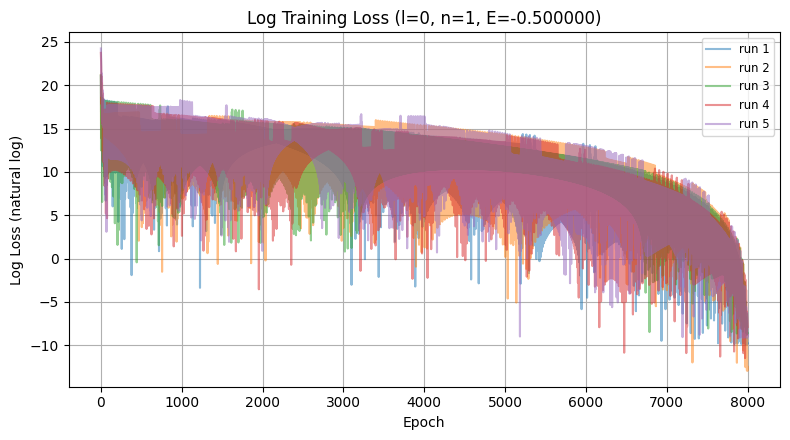

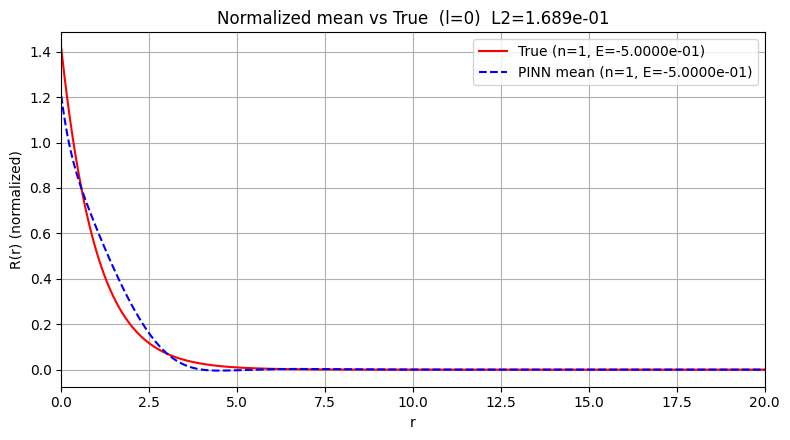

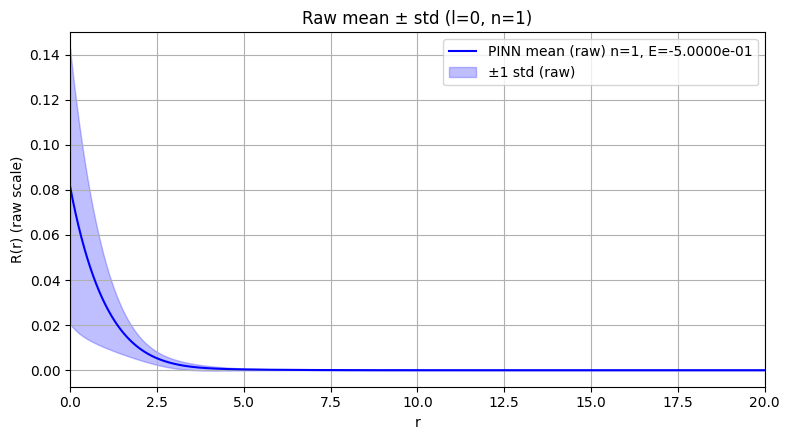


=== Running l=1, n=2, analytic E=-0.125000 ===


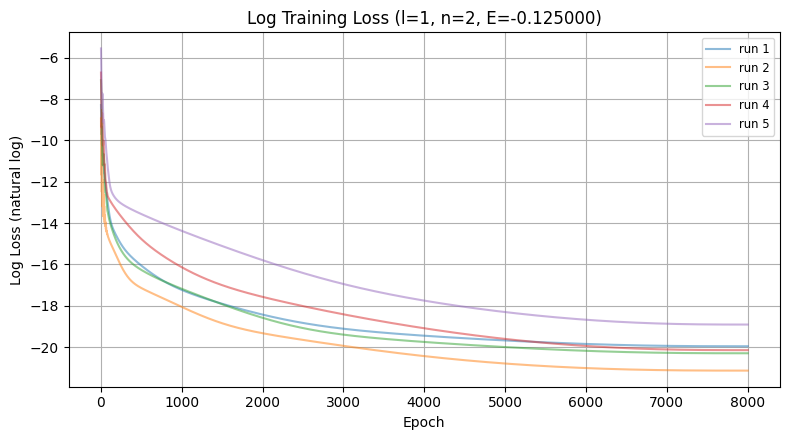

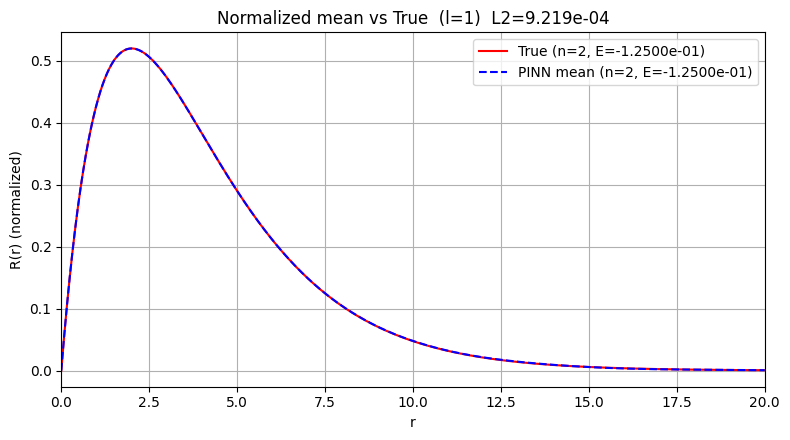

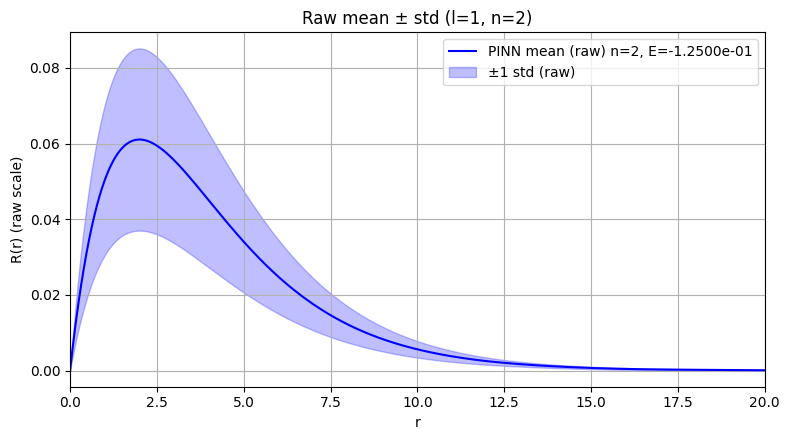


=== Running l=2, n=3, analytic E=-0.055556 ===


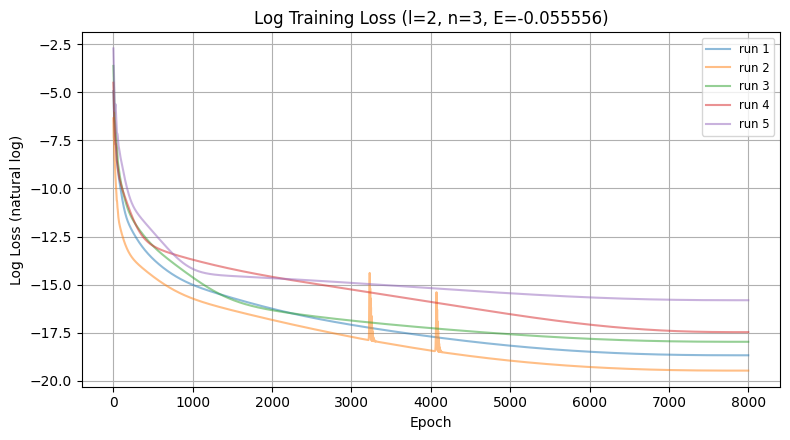

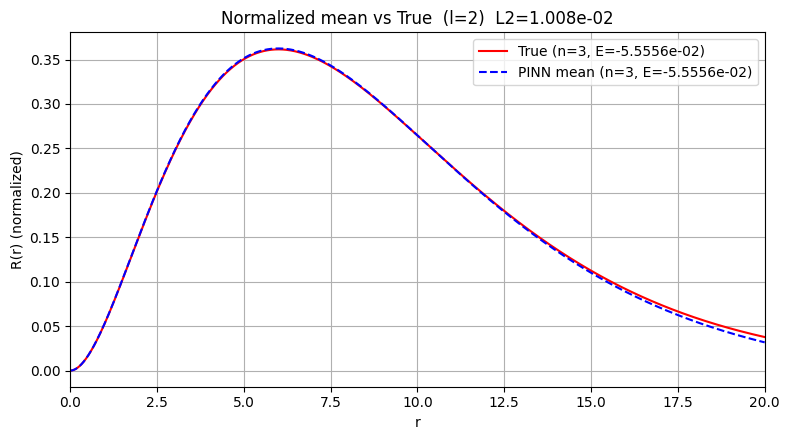

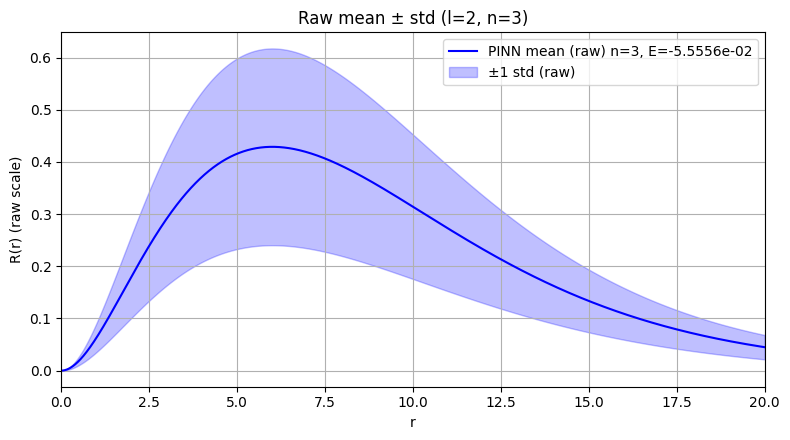


=== Running l=3, n=4, analytic E=-0.031250 ===


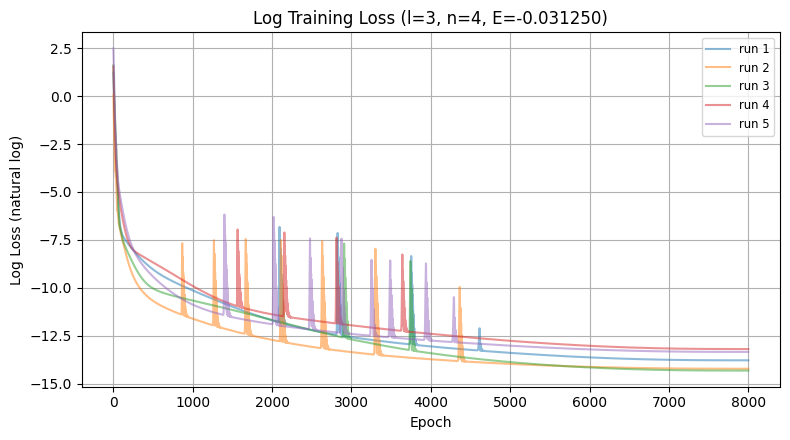

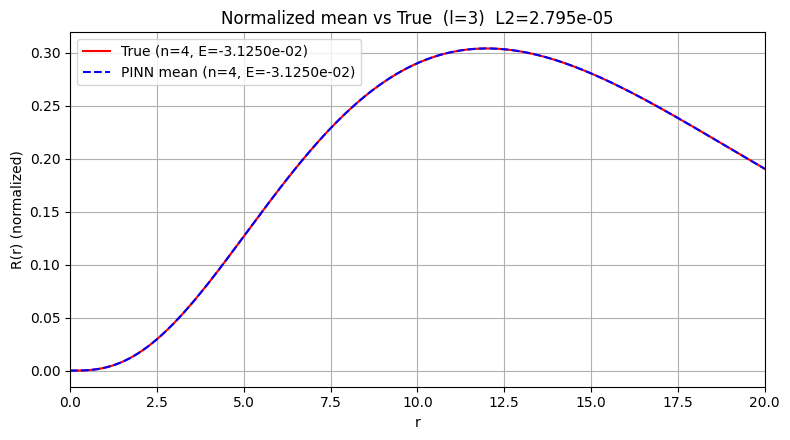

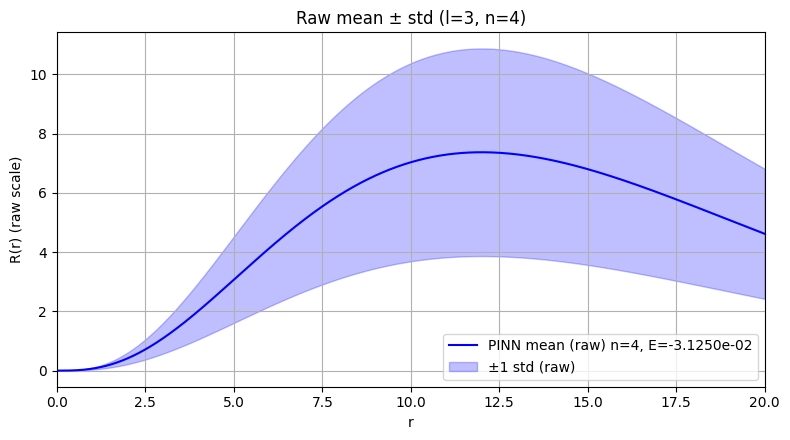


=== Running l=4, n=5, analytic E=-0.020000 ===


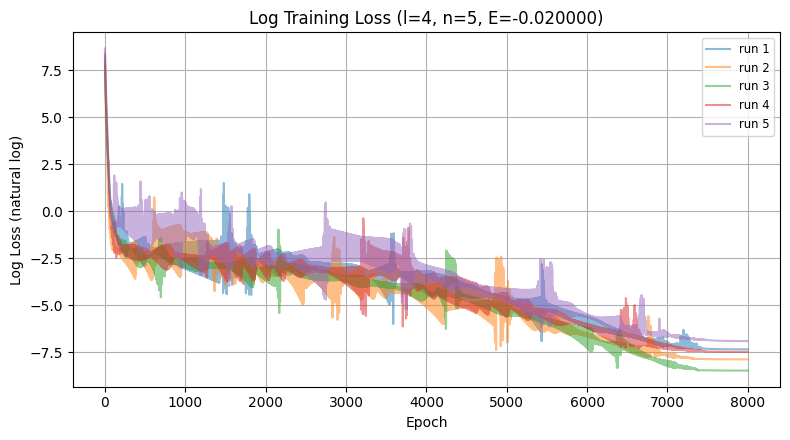

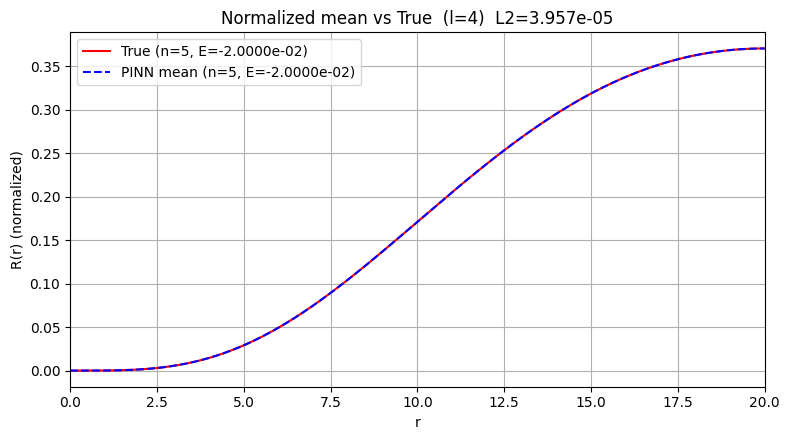

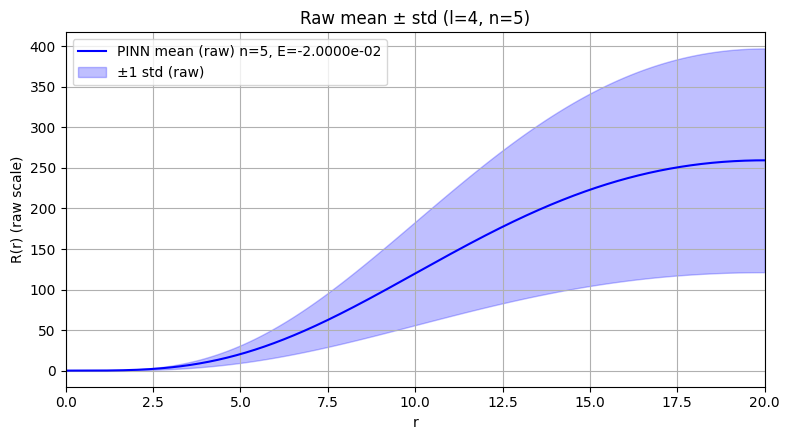

In [1]:
# Modified PINN script: records loss history and makes 3 plots per l:
# 1) log training loss, 2) normalized mean vs analytic (shows n & E), 3) raw mean ± std
# Based on the code you said works well; only minimal changes to record loss and plotting.

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad

# ----- User-configurable -----
l_values = [0, 1, 2, 3,4]   # values of l to run
n_runs = 5
r_min, r_max = 1e-8, 20.0   # extend r_max for larger-l tails
n_points = 6000             # number of r grid points
n_iter = 8000               # training iterations per run (tune as desired)
lr = 1e-4
layers = [1, 64, 64, 64, 64, 1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_base = 0

# ----- Net (same style you used) -----
class SineNet(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.linears = nn.ModuleList([
            nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)
        ])
        # keep default init; your original code worked well
        # Ensure model parameters are of type torch.float64
        self.double()

    def forward(self, x):
        x = self.linears[0](x)
        x = torch.sin(x)
        for layer in self.linears[1:-1]:
            x = torch.tanh(layer(x))
        x = self.linears[-1](x)
        return x

# ----- Output form for general n,l -----
# R(r) = r^l * exp(-r / n) * NN(r)
def R_pred(model, r, l, n):
    return (r ** l) * torch.exp(-r / float(n)) * model(r)

# ----- Physics loss (radial eqn for R) -----
def radial_residual(model, r, l, E, n):
    r = r.clone().requires_grad_(True)
    R = R_pred(model, r, l, n)
    dR = grad(R, r, torch.ones_like(R), create_graph=True)[0]
    d2R = grad(dR, r, torch.ones_like(dR), create_graph=True)[0]
    V = -1.0 / r
    lhs = d2R + (2.0 / r) * dR + 2.0 * (E - V - (l * (l + 1)) / (2.0 * r ** 2)) * R
    return torch.mean(lhs ** 2)

# ----- Training a single model (one seed) -----
# returns model and loss_history (list of floats)
def train_seed(seed, l, n, E, r_grid):
    torch.manual_seed(seed)
    model = SineNet(layers).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_iter)

    r = torch.tensor(r_grid, device=device, dtype=torch.float64).view(-1, 1)
    loss_history = []

    for i in range(1, n_iter + 1):
        optimizer.zero_grad()
        loss = radial_residual(model, r, l, E, n)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        scheduler.step()

        loss_history.append(float(loss.item()))

        # # optional light progress print
        # if (i % (n_iter // 4) == 0) or (i == 1):
        #     print(f"  seed {seed} l={l} n={n} iter {i}/{n_iter} loss={loss.item():.3e}")

    return model, np.array(loss_history, dtype=np.float64)

# ----- Evaluate model -> returns (r_np, pred_raw, pred_norm) -----
def evaluate(model, r_tensor, l, n):
    with torch.no_grad():
        pred_raw = R_pred(model, r_tensor, l, n).cpu().numpy().flatten()
    r_np = r_tensor.cpu().numpy().flatten()
    # normalized on r_grid
    norm = np.sqrt(np.trapz(pred_raw ** 2, r_np))
    pred_norm = pred_raw / (norm + 1e-16)
    return r_np, pred_raw, pred_norm

# ----- Analytic radial for n=l+1 (associated Laguerre reduces to 1) -----
def analytic_radial_n_eq_lplus1(r_np, l, n):
    raw = (r_np ** l) * np.exp(-r_np / float(n))
    norm = np.sqrt(np.trapz(raw ** 2, r_np))
    return raw / (norm + 1e-16)

# ----- Multiple runs for a given l ----- returns predictions, losses, analytic, and metadata -----
def runs_for_l(l, n_runs=n_runs):
    n = l + 1
    E = -1.0 / (2.0 * n * n)
    print(f"\n=== Running l={l}, n={n}, analytic E={E:.6f} ===")
    # prepare r grid tensor & numpy grid
    r_grid_np = np.linspace(r_min, r_max, n_points)
    r_grid_t = torch.tensor(r_grid_np, device=device, dtype=torch.float64).view(-1, 1)

    preds_raw = []
    preds_norm = []
    losses_all = []

    for seed_offset in range(n_runs):
        seed = seed_base + seed_offset
        model, loss_hist = train_seed(seed, l, n, E, r_grid_np)
        r_np, pred_raw, pred_norm = evaluate(model, r_grid_t, l, n)
        preds_raw.append(pred_raw)
        preds_norm.append(pred_norm)
        losses_all.append(loss_hist)

    preds_raw = np.array(preds_raw)    # shape (n_runs, n_points)
    preds_norm = np.array(preds_norm)
    losses_all = np.array([np.asarray(x) for x in losses_all])  # ragged; we'll handle lengths below

    # mean/std across runs for raw and normalized
    mean_raw = preds_raw.mean(axis=0)
    std_raw = preds_raw.std(axis=0)
    mean_norm = preds_norm.mean(axis=0)
    std_norm = preds_norm.std(axis=0)

    analytic = analytic_radial_n_eq_lplus1(r_grid_np, l, n)

    # align sign using a small-r index (to match analytic)
    idx_sign = min(10, len(r_grid_np)-1)
    if np.sign(mean_norm[idx_sign]) != np.sign(analytic[idx_sign]):
        mean_raw = -mean_raw
        preds_raw = -preds_raw
        std_raw = preds_raw.std(axis=0)
        mean_norm = -mean_norm
        preds_norm = -preds_norm
        std_norm = preds_norm.std(axis=0)

    # Normalize mean_norm again (numerical safety)
    mean_norm = mean_norm / (np.sqrt(np.trapz(mean_norm ** 2, r_grid_np)) + 1e-16)
    analytic_norm = analytic / (np.sqrt(np.trapz(analytic ** 2, r_grid_np)) + 1e-16)

    # L2 error (for info)
    L2 = np.sqrt(np.trapz((mean_norm - analytic_norm) ** 2, r_grid_np))

    return {
        'r_np': r_grid_np,
        'preds_raw': preds_raw,
        'preds_norm': preds_norm,
        'mean_raw': mean_raw,
        'std_raw': std_raw,
        'mean_norm': mean_norm,
        'std_norm': std_norm,
        'losses_all': losses_all,
        'analytic_norm': analytic_norm,
        'n': n,
        'E': E,
        'L2': L2
    }

# ----- Plotting helpers -----
def plot_log_loss(losses_all, l, n, E):
    # losses_all: array-like of shape (n_runs, epochs) but epochs can vary; pad with NaN
    n_runs = len(losses_all)
    max_epochs = max(arr.shape[0] for arr in losses_all)
    loss_matrix = np.full((n_runs, max_epochs), np.nan)
    for i, arr in enumerate(losses_all):
        loss_matrix[i, :arr.shape[0]] = arr
    log_loss = np.log(loss_matrix + 1e-16)
    # log_mean = np.nanmean(log_loss, axis=0)

    plt.figure(figsize=(8,4.5))
    for i in range(n_runs):
        plt.plot(np.arange(1, loss_matrix.shape[1]+1), log_loss[i], alpha=0.5, label=f'run {i+1}')
    # plt.plot(np.arange(1, loss_matrix.shape[1]+1), log_mean, color='black', linestyle='--', linewidth=2, label='mean log loss')
    plt.xlabel('Epoch')
    plt.ylabel('Log Loss (natural log)')
    plt.title(f'Log Training Loss (l={l}, n={n}, E={E:.6f})')
    plt.legend(loc='upper right', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_normalized_mean_vs_analytic(r_np, mean_norm, analytic_norm, l, n, E, L2):
    plt.figure(figsize=(8,4.5))
    plt.plot(r_np, analytic_norm, 'r-', label=f'True (n={n}, E={E:.4e})')
    plt.plot(r_np, mean_norm, 'b--', label=f'PINN mean (n={n}, E={E:.4e})')
    plt.xlabel('r')
    plt.ylabel('R(r) (normalized)')
    plt.title(f'Normalized mean vs True  (l={l})  L2={L2:.3e}')
    plt.legend()
    plt.xlim(0, min(20.0, r_max))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_raw_mean_std(r_np, mean_raw, std_raw, l, n, E):
    plt.figure(figsize=(8,4.5))
    plt.plot(r_np, mean_raw, 'b-', label=f'PINN mean (raw) n={n}, E={E:.4e}')
    plt.fill_between(r_np, mean_raw - std_raw, mean_raw + std_raw, color='blue', alpha=0.25, label='±1 std (raw)')
    plt.xlabel('r')
    plt.ylabel('R(r) (raw scale)')
    plt.title(f'Raw mean ± std (l={l}, n={n})')
    plt.legend()
    plt.xlim(0, min(20.0, r_max))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ----- Main driver: run for each l and plot results -----
if __name__ == "__main__":
    for l in l_values:
        results = runs_for_l(l, n_runs=n_runs)
        r_np = results['r_np']
        mean_raw = results['mean_raw']
        std_raw = results['std_raw']
        mean_norm = results['mean_norm']
        std_norm = results['std_norm']
        analytic_norm = results['analytic_norm']
        losses_all = results['losses_all']
        n = results['n']
        E = results['E']
        L2 = results['L2']

        # print(f">>> l={l}, n={n}, E={E:.6e}, L2 (mean_norm vs analytic) = {L2:.3e}")

        # Plot 1: log loss
        plot_log_loss(losses_all, l, n, E)

        # Plot 2: normalized mean vs analytic (with n & E in legend/title)
        plot_normalized_mean_vs_analytic(r_np, mean_norm, analytic_norm, l, n, E, L2)

        # Plot 3: raw mean ± std
        plot_raw_mean_std(r_np, mean_raw, std_raw, l, n, E)